## CUSTOMER PURCHASE PREDICTION - ML PROJECT

- This is going to be a binary classification project and the goal of the project will be `Given customer information, predict whether the customer will purchase a product.`

In [39]:
import numpy as np
import pandas as pd

In [40]:
np.random.seed(42) # TO control the randomness

In [41]:
n = 1000

In [42]:
df = pd.DataFrame({
    "age" : np.random.randint(18,65,n),
    "income" : np.random.randint(20000, 150000, n),
    "previous_purchases" : np.random.randint(0,10,n),
    "city" : np.random.choice(
        ["Hyderabad", 'Delhi', "Mumbai", "Banglore"],
        n
    ),
    "device" : np.random.choice(
        ['Mobile', 'Desktop', 'Tablet'],
        n
    )
})

In [43]:
df.head()

,age,income,previous_purchases,city,device
0,56,136748,1,Banglore,Desktop
1,46,25287,3,Delhi,Tablet
2,32,146593,0,Delhi,Desktop
3,60,54387,2,Delhi,Tablet
4,25,28512,8,Banglore,Tablet


In [44]:
score = (
    0.03 * df['age']
    + 0.00001 * df['income']
    + 0.5 * df['previous_purchases']
    + np.random.normal(0, 1, n)
)

df["purchased"] = (score > 2.5).astype(int) # We are giving a calculated target value here

In [45]:
df.head()

,age,income,previous_purchases,city,device,purchased
0,56,136748,1,Banglore,Desktop,1
1,46,25287,3,Delhi,Tablet,0
2,32,146593,0,Delhi,Desktop,0
3,60,54387,2,Delhi,Tablet,0
4,25,28512,8,Banglore,Tablet,1


In [46]:
# Our Target

y = df['purchased']

In [47]:
# features

X = df.drop("purchased", axis = 1)

### Splitting the data before applying any transformation for the columns

In [48]:
# Splitting of the data before any transformation

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2, # 20% of the data reserved for testing
    random_state = 42, # For reproducability
    stratify = y # Preserving the same class distribution in both training and testing
)

In [49]:
# Seperate the numerical and the categorical columns

numerical_features = [
    "age",
    "income",
    "previous_purchases"
]

categorical_features = [
    "city",
    "device"
]

### Processing the data comes after the splitting
- This is because `The test set must not influence how preprocessing is learned.`

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [51]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")), # Replaces the missing values with median,
    ("scaler", StandardScaler()) # This is a scaling technique so that the values can be brought to a similar scale.
])

In [52]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ("Imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [53]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [54]:
from sklearn.linear_model import LogisticRegression

model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

### Process we followed above.
1. We defined a pipeline to transform numerical columns.
2. We defined a pipeline to transform categorical columns.
3. Then using column transformer we have transformed the data.
4. Then using the Pipeline we have applied the logistic regression to the data.

In [55]:
# We train the data using the .fit method

model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [56]:
# After training we test the predictions using .predict

y_pred = model_pipeline.predict(X_test) # Here we didnt manually transformed the data in the test set.
# Transformation was done by the pipeline.

In [57]:
# Evaluating the model

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Logistic Regression - Results", end="\n\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

Logistic Regression - Results

Confusion Matrix:
[[ 21  13]
 [  8 158]]
Accuracy: 0.895
Precision: 0.9239766081871345
Recall: 0.9518072289156626
F1-Score: 0.9376854599406528
ROC-AUC: 0.784727143869596


### Understanding:
--> Confusion Matrix:
```text
                    Predicted
                  0          1
              ┌──────────┬──────────┐
Actual     0  │    18    │    15    │
              ├──────────┼──────────┤
           1  │    11    │   156    │
              └──────────┴──────────┘
```
- So from the matrix we can see that:
1. TN = 18
2. FP = 15
3. FN = 11
4. TP = 156

--> Accuracy: 87% of all predictions were correct.
--> Precision: 91.2% of the times, the model makes a correct prediction.
--> Recall: Our model successfully identified 93.4% of all customers who actually purchased.
--> F1-Score: 0.923 which means our model has good balance in precision and recall.
--> ROC-AUC: 0.738 meaans model has useful discriminatory ability, but it isn't exceptionally strong.

##### The model correctly classifies 87% of customers. When it predicts that a customer will purchase, it is correct about 91% of the time. It identifies about 93% of actual purchasers. The F1 score of 92.3% indicates a good balance between precision and recall. However, its ROC-AUC of 0.74 suggests that its ability to distinguish purchasers from non-purchasers across different probability thresholds is only moderate.

In [58]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model_pipeline,
    X_train,
    y_train,
    cv=5, # Number of folds
    scoring="f1" # This can be anything of the 5, depending upon the requirement of the problem.
)

In [59]:
print("CV-Scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())

CV-Scores: [0.93140794 0.9010989  0.95652174 0.91512915 0.93283582]
Mean CV F1: 0.9273987109309276


### This is important because sklearn correctly performs the preprocessing inside every fold. 
- Ex:
```text
Fold 1

Training portion
      ↓
Fit Imputer
      ↓
Fit Scaler
      ↓
Fit Encoder
      ↓
Fit Logistic Regression
      ↓
Validation portion
      ↓
Transform using learned preprocessing
      ↓
Evaluate
```
- Then it repeats this for every fold.
- This prevents `data leakage during cross-validation.`

### Now comes the hyperparameter tuning

In [60]:
from sklearn.model_selection import GridSearchCV

- Our Logistic regression has some hyperparameters like `C, penalty`.
- `C` --> Inverse of the regularization strength.

- Small C --> stronger regularization
- Large C --> weaker regularization

- Ex:
```text
C = 0.01  → strong regularization
C = 0.1   → fairly strong
C = 1     → default-ish
C = 10    → weak
C = 100   → very weak
```
- Instead of manually trying every possible C value, we use the gridsearch cross validation.

In [61]:
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

- Parameters grid is the set of hyperparameters that we want to tune.
- Ex:
```text
param_grid = {
    "model__C": [0.1, 1, 10],
    "model__max_iter": [100, 200]
}
```

- For the above parameters grid, the GridSearchCv will perform every combination:
```text
C = 0.1, max_iter = 100
C = 0.1, max_iter = 200

C = 1,   max_iter = 100
C = 1,   max_iter = 200

C = 10,  max_iter = 100
C = 10,  max_iter = 200
```

In [62]:
# Create GridSearchCV

grid_search = GridSearchCV(
    model_pipeline, # The model we want to tune, this is trained on the train data only
    param_grid, # These are the hyperparameters we want to experiment
    cv=5, # Number of folds
    scoring="f1", # Use this metric to identify the best performer
    n_jobs = -1 # Use all the available CPU cores to perform the calculations in parallel
)

- Scoring can be done for any metric depending upon the requirement.
- Ex:
```text
Cancer --> Missing a positive case is extremely costly --> Prioritize `Recall`
Spam --> Accidently marking legitimate emails as spam is costly --> Prioritize `Precision`
Our Problem --> We might care about identifying as many potential purchasers as possible --> Recall would be appropriate.
```

In [63]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate para

In [64]:
# Get the best parameter with its score

print(grid_search.best_params_)
print(grid_search.best_score_)

{'model__C': 0.1}
0.9290090895341052


In [65]:
# Get the model with best parameters as the best model.

best_model = grid_search.best_estimator_
print(best_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'income',
                                                   'previous_purchases']),
                                                 ('cat',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ign

#### Now what is gridsearch actually doing here ?
- Suppose we give a parameter grid like the one in the above example
- For that, there will be 6 combinations in total, so grid search does this:
```text
             GridSearchCV
                  ↓
       Try every combination
                  ↓
    ┌──────┬──────┬──────┐
    ↓      ↓      ↓      ↓
 Config 1 Config 2 ... Config 6
    ↓      ↓             ↓
  5-fold  5-fold        5-fold
    ↓      ↓             ↓
 Mean F1 Mean F1       Mean F1
    └──────┴──────┬──────┘
                   ↓
          Highest Mean F1
                   ↓
          Best Parameters
```

In [66]:
# Then we test the best model with best parameter on the test data to get the prediction.

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

In [67]:
print("Logistic Regression Post Hyperparameter tuning - Result", end="\n\n")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Logistic Regression Post Hyperparameter tuning - Result

Accuracy: 0.875
Precision: 0.8895027624309392
Recall: 0.9698795180722891
F1: 0.9279538904899135
ROC-AUC: 0.940644932671864


Logistic Regression - Results

- Accuracy: 0.87
- Precision: 0.9122807017543859
- Recall: 0.9341317365269461
- F1-Score: 0.9230769230769231
- ROC-AUC: 0.7397931409907457

- We see that overall metrics remain same except the ROC-AUC value has increased.

### Now we will train different models on different algorithms on the same problem and determine which one is actually best.

### Decision Tree

- Our Preprocessing for the data remains same.

In [68]:
from sklearn.tree import DecisionTreeClassifier

tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state = 42
    ))
])

In [69]:
tree_pipeline.fit(X_train, y_train)

tree_pred = tree_pipeline.predict(X_test)
tree_proba = tree_pipeline.predict_proba(X_test)[:,1]

In [70]:
print("Decision Tree - Results", end="\n\n")
print("Accuracy:", accuracy_score(y_test, tree_pred))
print("Precision:", precision_score(y_test, tree_pred))
print("Recall:", recall_score(y_test, tree_pred))
print("F1:", f1_score(y_test, tree_pred))
print("ROC-AUC:", roc_auc_score(y_test, tree_proba))

Decision Tree - Results

Accuracy: 0.835
Precision: 0.893491124260355
Recall: 0.9096385542168675
F1: 0.9014925373134328
ROC-AUC: 0.6901133947554925


- Now, Decision tree being a single unit is more prone to overfitting. So we will move to Random Forest.

### Random Forest

In [71]:
from sklearn.ensemble import RandomForestClassifier

In [72]:
forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42
    ))
])

In [73]:
forest_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

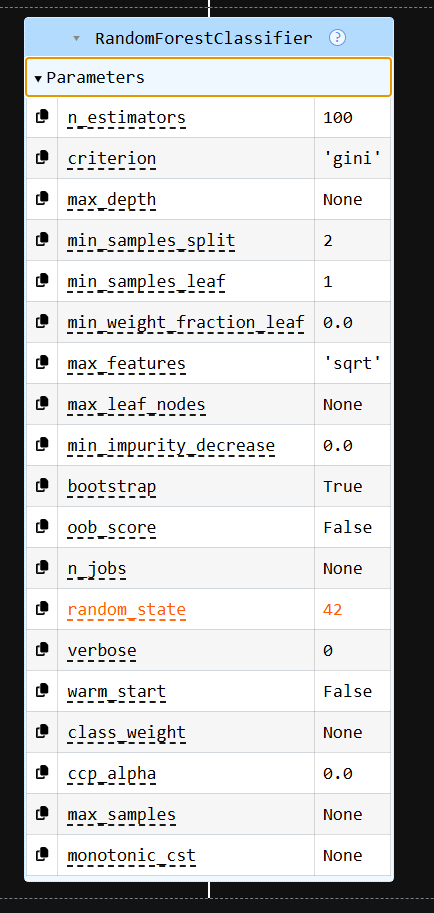
- These are all the hyperparameters of Random Forest

In [74]:
# We make the prediction on the test data

forest_pred = forest_pipeline.predict(X_test)
forest_proba = forest_pipeline.predict_proba(X_test)[:, 1]

In [75]:
print("Random Forest - Results", end="\n\n")
print("Accuracy:", accuracy_score(y_test, forest_pred))
print("Precision:", precision_score(y_test, forest_pred))
print("Recall:", recall_score(y_test, forest_pred))
print("F1:", f1_score(y_test, forest_pred))
print("ROC-AUC:", roc_auc_score(y_test, forest_proba))

Random Forest - Results

Accuracy: 0.885
Precision: 0.8994413407821229
Recall: 0.9698795180722891
F1: 0.9333333333333333
ROC-AUC: 0.924078667611623


- These results are way better than the Decision tree.

In [76]:
# Tuning the Random Forest

rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

In [77]:
rf_grid = GridSearchCV(
    forest_pipeline,
    rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [78]:
rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 5, ...], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each

In [79]:
print("Best parameters:")
print(rf_grid.best_params_)

print("Best CV F1:")
print(rf_grid.best_score_)

Best parameters:
{'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV F1:
0.9276380622513049


In [80]:
best_rf = rf_grid.best_estimator_

In [81]:
best_rf_pred = best_rf.predict(X_test)
best_rf_proba = best_rf.predict_proba(X_test)[:, 1]

In [82]:
print("Random Forest After Tuning - Results", end="\n\n")
print("Accuracy:", accuracy_score(y_test, best_rf_pred))
print("Precision:", precision_score(y_test, best_rf_pred))
print("Recall:", recall_score(y_test, best_rf_pred))
print("F1:", f1_score(y_test, best_rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, best_rf_proba))

Random Forest After Tuning - Results

Accuracy: 0.865
Precision: 0.8677248677248677
Recall: 0.9879518072289156
F1: 0.923943661971831
ROC-AUC: 0.9445428773919206


### Now there is no one model that is "best" across every metric. 
- For all the metrics Random forest won, but for ROC-AUC Logistic Regression remains at top.
- So which model to choose entirely depends on the model performance after tuning on the relevant metric for that particular problem.

- Now in this example we were compairing models using their `test-set performance`.
- But in real ML workflow, we dont do that as it can eventually result in optimization against the test set.
- Ideal ML FLOW is:
```text
Training Data
      │
      ▼
Cross Validation
      │
      ├── Logistic Regression
      ├── Decision Tree
      └── Random Forest
      │
      ▼
Select model
      │
      ▼
Tune hyperparameters
      │
      ▼
Final model
      │
      ▼
──────────────
Test Set
──────────────
      │
      ▼
Final evaluation
```

- Now ideally we should not conclude that `our model is the best model in existence`.
- We just simply say that `Among all the models with different hyperparameters we testing for this problem, this was the best performer.`

- Until now we have inspected `How accurate is our model ?`
- Now we will work on `Why is the model making these predictions ?`

### Now, we will see what the model actually learned.

In [83]:
preprocessor = best_rf.named_steps["preprocessor"]
print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'income', 'previous_purchases']),
                                ('cat',
                                 Pipeline(steps=[('Imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['city', 'device'])])


In [84]:
model = best_rf.named_steps["model"]
print(model)

RandomForestClassifier(max_depth=5, min_samples_split=5, n_estimators=200,
                       random_state=42)


In [85]:
feature_names = preprocessor.get_feature_names_out()
print(feature_names)

['num__age' 'num__income' 'num__previous_purchases' 'cat__city_Banglore'
 'cat__city_Delhi' 'cat__city_Hyderabad' 'cat__city_Mumbai'
 'cat__device_Desktop' 'cat__device_Mobile' 'cat__device_Tablet']


In [86]:
importances = model.feature_importances_

In [87]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

In [88]:
importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

In [89]:
print(importance_df)

                   feature  importance
2  num__previous_purchases    0.559635
1              num__income    0.182400
0                 num__age    0.173752
6         cat__city_Mumbai    0.028094
7      cat__device_Desktop    0.010553
5      cat__city_Hyderabad    0.009631
9       cat__device_Tablet    0.009328
3       cat__city_Banglore    0.008945
4          cat__city_Delhi    0.008882
8       cat__device_Mobile    0.008780


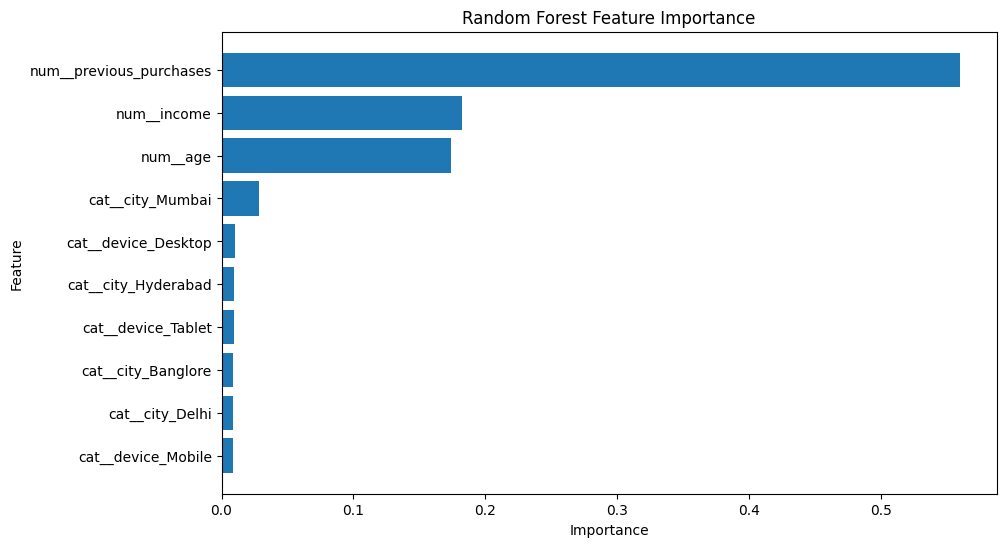

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

- We understand that the num_previous_purchases column is the highest influencer in the models prediction.

- Random Forest's built int `feature_importances_` is called as the `impurity-based feature importance` or `Mean Decrease in Impurity (MDI)`.
- It is useful, but it has **Limitations**.
- Ex, it can favor certain types of features, especially features with many possible split points.

- So we will use a more robust technique called as `Permuation Importance`. It basically says, if i randomly shuffle this feature, how much does the model's performance deteriorate ?

- Ex:
```text
Original model F1:
93.5%

Shuffle income:
F1 → 85%

Shuffle age:
F1 → 91%

Shuffle device:
F1 → 93%
```
- Then we can conclude:
```text
income → highly important
age → moderately important
device → relatively unimportant
```

### Permutation Importance.

In [91]:
# Permutation Importance
 
# Importance = Original Score - Permuted score

from sklearn.inspection import permutation_importance

In [92]:
result = permutation_importance(
    best_rf,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [93]:
print(len(feature_names))
print(len(result.importances_mean))

10
5


In [94]:
feature_names = preprocessor.get_feature_names_out()

In [95]:
feature_names = X_test.columns

perm_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": result.importances_mean
})

In [96]:
print(feature_names.shape)

(5,)


In [97]:
perm_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": result.importances_mean
})

In [98]:
perm_importance_df = perm_importance_df.sort_values(
    "importance",
    ascending=False
)

In [99]:
print(perm_importance_df)

              feature  importance
2  previous_purchases    0.045752
0                 age    0.005576
3                city    0.003515
1              income    0.003436
4              device    0.002558


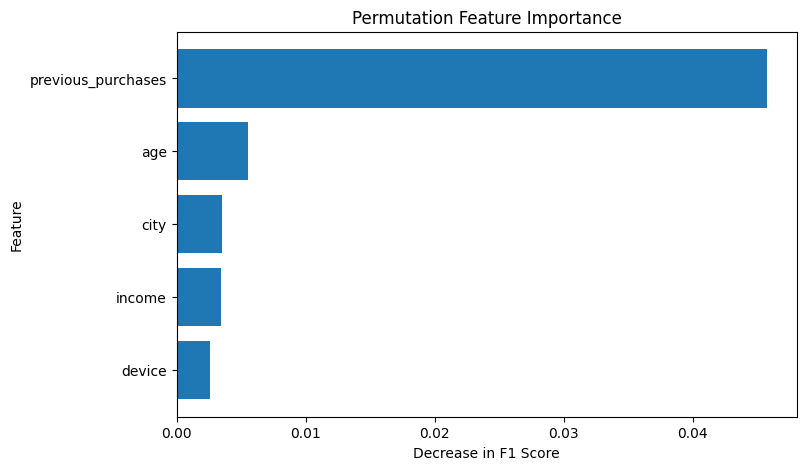

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.barh(
    perm_importance_df["feature"],
    perm_importance_df["importance"]
)

plt.xlabel("Decrease in F1 Score")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")

plt.gca().invert_yaxis()

plt.show()

- Similar Results.

### Saving the model

In [101]:
import joblib

In [102]:
joblib.dump(
    best_rf,
    "customer_purchase_model.pkl"
)

['customer_purchase_model.pkl']

- After saving it we can use it in another file by loading it. We will add that part here.

- The `.pkl` file contains our entire pipeline not just random forest. That is important.

### SHAP --> 

- We have identified the feature importance above - This was more global.
- But suppose we are looking at the data at customer level - And we want to identify what the model gave this prediction to this customer.
- This is where Shap comes in.

- SHAP breaks a prediction into contributions from individual features.
- Ex:
```text
Base prediction
      +
Age contribution
      +
Income contribution
      +
Previous purchases contribution
      +
City contribution
      +
Device contribution
      =
Final prediction
```
- Then,
```text
Base prediction                 50%
Age                             +5%
Income                          -3%
Previous purchases             +35%
City                            +2%
Device                          +2%
                                ────
Final prediction                91%
```

- Here Shap is basically answering: `How much did each feature contribute to moving this prediction away from the baseline.`

- What is `baseline` ?

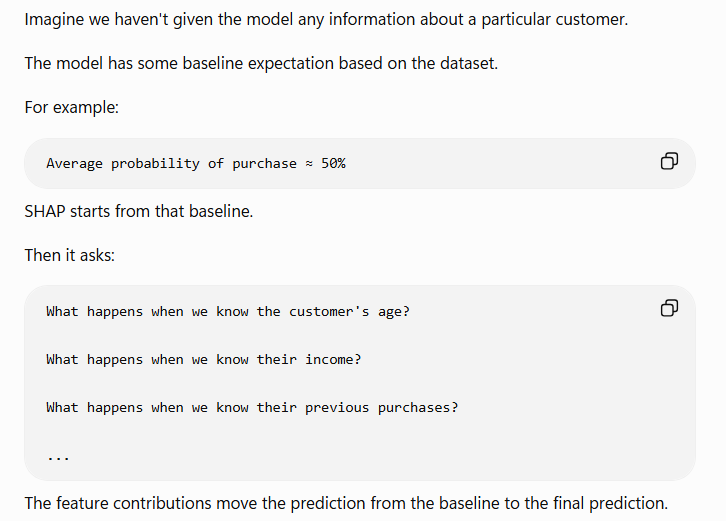

In [103]:
# SHAP

preprocessor = best_rf.named_steps["preprocessor"]
rf_model = best_rf.named_steps["model"]

In [104]:
X_test_transformed = preprocessor.transform(X_test)

In [105]:
!pip install shap --quiet

In [106]:
import shap
explainer = shap.TreeExplainer(rf_model)

c:\Users\mzama\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [107]:
shap_values = explainer.shap_values(X_test_transformed)

C:\Users\mzama\AppData\Local\Temp\ipykernel_31164\654530092.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
c:\Users\mzama\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
c:\Users\mzama\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\plots\_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


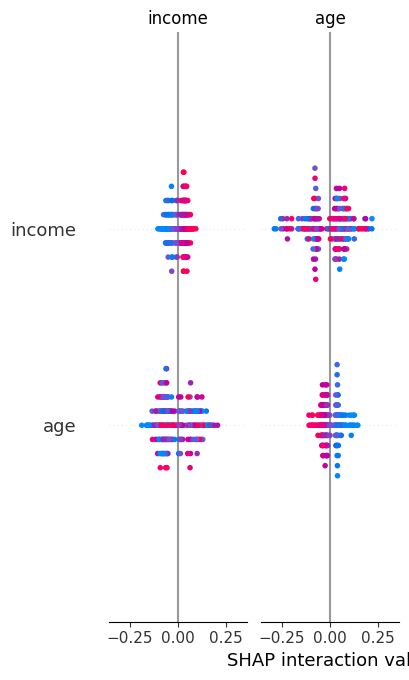

In [108]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)